# Stop-Loss Layer Pricing
## A Monte Carlo Approach

This notebook prices a **Stop-Loss** reinsurance treaty using the `reinsure_pricing` engine.

Unlike the per-occurrence XL treaty in notebook 01, the Stop-Loss operates on the
**aggregate annual loss** — the reinsurer pays when the total losses for the entire
accident year exceed the attachment point.

**Treaty structure:** 20M xs 10M — the reinsurer covers aggregate annual losses
between 10M and 30M.

**Methodology:**
1. Define claim frequency and individual loss severity distributions
2. Simulate 100,000 accident years
3. Aggregate individual losses per year and apply the Stop-Loss treaty
4. Compute risk measures from the ceded loss distribution
5. Derive a risk-adjusted technical premium

In [41]:
# Imports
from reinsure_pricing.frequency import PoissonFrequency, NegativeBinomialFrequency
from reinsure_pricing.severity import LognormalSeverity
from reinsure_pricing.treaties import StopLoss
from reinsure_pricing.simulation import MonteCarloEngine
from reinsure_pricing.risk_measures import compute_risk_measures
from reinsure_pricing.pricing import TechnicalPricer
from reinsure_pricing.plots import plot_ceded_loss_distribution, plot_sensitivity
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Distribution Assumptions

We use the same portfolio as notebook 01 for comparability:
- **Frequency:** Poisson(λ=120) — approximately 120 claims per accident year
- **Severity:** Lognormal(μ=10.5, σ=1.2) — mean individual loss ~332,000

The expected aggregate annual loss is approximately:

$$E[S] = E[N] \times E[X] = 120 \times 332{,}000 \approx 39{,}840{,}000$$

The Stop-Loss attachment of 50M is set above this expected aggregate,
meaning the treaty is triggered only in years where losses are
significantly above average.

In [42]:
# Frequency and severity
frequency = PoissonFrequency(lambda_=120)
severity  = LognormalSeverity(mu=10.5, sigma=1.2)

expected_aggregate = frequency.mean() * severity.mean()

print(f"Frequency — Poisson(λ={frequency.mean():.0f})")
print(f"Severity  — Lognormal(μ=10.5, σ=1.2)")
print(f"\nExpected aggregate annual loss : {expected_aggregate:,.0f}")

Frequency — Poisson(λ=120)
Severity  — Lognormal(μ=10.5, σ=1.2)

Expected aggregate annual loss : 8,952,933


## 2. Treaty Structure

We price a **20M xs 50M** Stop-Loss treaty:

| Parameter | Value |
|---|---|
| Attachment point | 10,000,000 |
| Cap | 20,000,000 |
| Exhaustion point | 30,000,000 |

The reinsurer pays `min(max(S - 10M, 0), 20M)` where S is the total
aggregate annual loss.

The attachment is set at **125% of the expected aggregate** — the treaty
only triggers in years where losses are materially worse than average.

### XL vs Stop-Loss — key difference

| | Excess-of-Loss | Stop-Loss |
|---|---|---|
| Applied to | Each individual loss | Annual aggregate loss |
| Triggered by | Single large claim | Bad aggregate year |
| Protects against | Severity risk | Frequency + severity combined |

In [43]:
# Treaty definition
treaty = StopLoss(attachment=10_000_000, cap=20_000_000)

print(f"Treaty: {treaty.cap/1e6:.0f}M xs {treaty.attachment/1e6:.0f}M Stop-Loss")
print(f"  Attachment       : {treaty.attachment:>12,.0f}")
print(f"  Cap              : {treaty.cap:>12,.0f}")
print(f"  Exhaustion point : {treaty.attachment + treaty.cap:>12,.0f}")
print(f"\n  Attachment / Expected Aggregate : "
      f"{treaty.attachment / expected_aggregate:.1%}")

Treaty: 20M xs 10M Stop-Loss
  Attachment       :   10,000,000
  Cap              :   20,000,000
  Exhaustion point :   30,000,000

  Attachment / Expected Aggregate : 111.7%


## 3. Monte Carlo Simulation

For each simulated accident year:
1. Draw claim count N from Poisson(120)
2. Draw N individual losses from Lognormal(10.5, 1.2)
3. Sum all losses to get the aggregate annual loss S
4. Apply Stop-Loss: `min(max(S - 50M, 0), 20M)`

The treaty triggers only when S exceeds 50M — expect a high proportion
of years with zero ceded loss.

In [44]:
# Run simulation
engine = MonteCarloEngine(
    frequency=frequency,
    severity=severity,
    treaty=treaty,
    n_simulations=100_000,
    random_state=42,
)
results = engine.run()

print(f"Simulation complete — {len(results.ceded_losses):,} accident years")
print(f"Years with no ceded loss : {(results.ceded_losses == 0).mean():.1%}")
print(f"Years with ceded loss    : {(results.ceded_losses > 0).mean():.1%}")

Simulation complete — 100,000 accident years
Years with no ceded loss : 76.2%
Years with ceded loss    : 23.8%


## 4. Risk Measures

In [45]:
# Risk measures
rm = compute_risk_measures(results, treaty_limit=treaty.cap)
print(rm.summary())

─────────────────────────────────────────────
                RISK MEASURES                
─────────────────────────────────────────────
Expected Ceded Loss   :         294,615
Std Deviation         :         781,397
Coeff of Variation    :           2.652
Skewness              :           4.173
─────────────────────────────────────────────
VaR  95%              :       1,909,102
VaR  99%              :       3,722,873
VaR  99.5%            :       4,512,309
─────────────────────────────────────────────
TVaR 95%              :       3,047,985
TVaR 99%              :       4,932,923
TVaR 99.5%            :       5,793,785
─────────────────────────────────────────────
Prob of Attachment    :           23.8%
Prob of Exhaustion    :            0.0%
─────────────────────────────────────────────


## 5. Ceded Loss Distribution

For a Stop-Loss treaty, the distribution is highly bimodal:
- A large mass at zero (years where aggregate losses stayed below attachment)
- A spread of positive ceded losses in years where the attachment was breached

The proportion of zero years is noted in the subtitle.

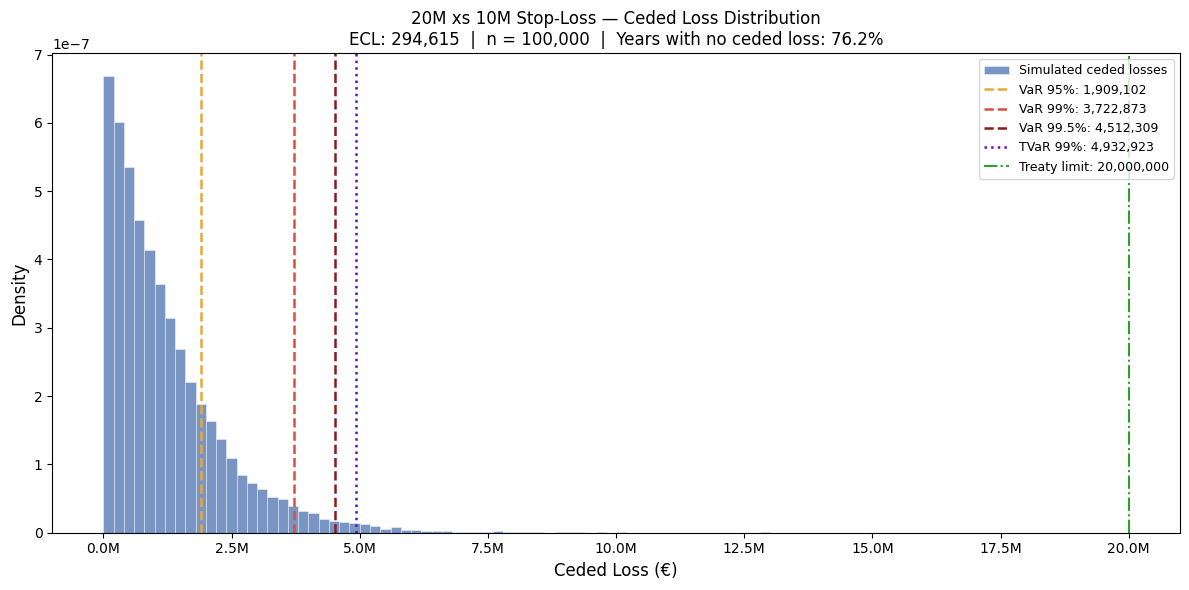

In [46]:
# Plot ceded loss distribution
fig = plot_ceded_loss_distribution(
    results=results,
    risk_measures=rm,
    treaty_limit=treaty.cap,
    title="20M xs 10M Stop-Loss — Ceded Loss Distribution",
)
plt.show()

## 6. Technical Pricing

In [47]:
# Technical premium
pricer = TechnicalPricer(
    expected_ceded_loss=results.expected_ceded_loss,
    tvar_99=results.tvar_99,
    expense_load=0.05,
    profit_load=0.08,
    cost_of_capital=0.10,
)

pricing = pricer.price(treaty_limit=treaty.cap)
print(pricing.summary())

Expected Ceded Loss  :         294,615
Expense Loading      :          14,731
Profit Loading       :          23,569
Capital Load         :         463,831
────────────────────────────────────────
Technical Premium    :         796,746
Rate on Line         :           3.98%


## 7. Sensitivity Analysis — Varying the Attachment

We vary the attachment point from 5M to 25M to show how the pricing
responds to changes in the trigger level.

Higher attachment → harder to trigger → lower ECL and premium.
Lower attachment → triggered more often → higher ECL and premium.

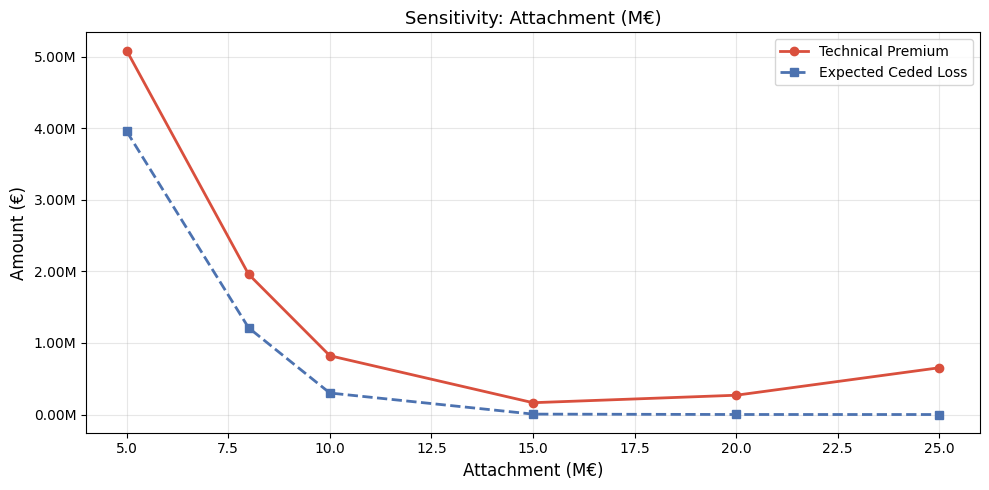

In [48]:
# Sensitivity: vary attachment
attachments = [5_000_000, 8_000_000, 10_000_000,
               15_000_000, 20_000_000, 25_000_000]
premiums_list = []
ecls_list = []

for att in attachments:
    t = StopLoss(attachment=att, cap=20_000_000)
    e = MonteCarloEngine(frequency, severity, t,
                         n_simulations=50_000, random_state=42)
    r = e.run()
    p = TechnicalPricer(
        expected_ceded_loss=r.expected_ceded_loss,
        tvar_99=r.tvar_99,
        expense_load=0.05,
        profit_load=0.08,
        cost_of_capital=0.10,
    )
    premiums_list.append(p.technical_premium())
    ecls_list.append(r.expected_ceded_loss)

fig = plot_sensitivity(
    parameter_values=[a/1e6 for a in attachments],
    premiums=premiums_list,
    ecls=ecls_list,
    parameter_name="Attachment (M€)",
)
plt.show()

## 8. Comparison with XL Treaty

The Stop-Loss and XL treaties protect against different risks:

| Metric | XL (5M xs 1M) | Stop-Loss (20M xs 10M) |
|---|---|---|
| Protects against | Individual large claims | Bad aggregate years |
| Attachment | Per-occurrence retention | Aggregate annual threshold |
| Prob of attachment | ~29% | see above |
| Rate on Line | see notebook 01 | see above |

The Stop-Loss is typically cheaper on a Rate on Line basis because it
requires the entire portfolio to perform badly before triggering —
individual large claims are absorbed within the aggregate.